In [20]:
import numpy as np
import cv2
import os
import pandas as pd
from PIL import Image
import h5py
import matplotlib.pyplot as plt
from scipy import io
from time import time
import sys
print(os.getcwd())

/Users/matte/Library/CloudStorage/GoogleDrive-matteobonotto90@gmail.com/Other computers/Dell Eni/Prove/PyTorch-Lightning-template/notebooks


In [29]:
paths_load = [
    r'../data/fashion-mnist/fashion-mnist_train.csv',
    r'../data/fashion-mnist/fashion-mnist_test.csv'
    ]

n_scale = 8

paths_save = [
    '../data/fashion-mnist/fashion-mnist_{}x{}_train'.format(n_scale*28,n_scale*28),
    '../data/fashion-mnist/fashion-mnist_{}x{}_test'.format(n_scale*28,n_scale*28),
    ]

for fileload, filesave in zip(paths_load, paths_save):
    print('Processing {}'.format(filesave))
    data = pd.read_csv(fileload, low_memory=False).to_numpy()
    X,y = data[:,1:], data[:,0].reshape(-1,1)
    dims = X.shape
    dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
    X = X.reshape(dims)

    X_resize = np.zeros((
        X.shape[0],
        n_scale*X.shape[1],
        n_scale*X.shape[2]))
    
    for i in range(X.shape[0]):
        if i/10000 == i//10000:
            print('   -> Step {} of {}'.format(i,X.shape[0]))
        x = X[i,...]
        im = Image.fromarray(np.uint8(x)).convert('L').resize(
            (n_scale*x.shape[0],n_scale*x.shape[1]), Image.Resampling.LANCZOS
        )
        X_resize[i,...] = np.asarray(im)

    X = X_resize.astype(dtype='float32')
    print('X size (GB): {:}'.format(sys.getsizeof(X)/1e+9))
    print('   Saving ...')
    
    #TODO 
    
    mdict = {'X':X}
    # t_start = time()
    # io.savemat(filesave + '.mat',mdict)
    # print(time() - t_start)
    
    # t_start = time()
    # compression = "gzip" #lzf
    # with h5py.File(filesave + '.h5', 'w') as hf:
    #     hf.create_dataset('X', data=X, compression=compression,shape=X.shape)
    #     # hf.create_dataset('y', data=y, compression=compression,shape=y.shape)
    # hf.close()
    # print(time() - t_start)

    if os.path.isfile(filesave + '.h5'):
        os.remove(filesave + '.h5')
    
    t_start = time()
    compression = "lzf" #lzf # gzip
    with h5py.File(filesave + '.h5', 'w') as hf:
        kwargs = {
            'dtype' : 'float32',
            'compression' : compression, 
            # 'compression_opts' : 0
            }
        hf.create_dataset('X',data=X,shape=X.shape,chunks=(512,28*n_scale,28*n_scale),**kwargs)
        hf.create_dataset('y',data=y,shape=y.shape,chunks=(512,1),**kwargs)
    hf.close()

    print('Done saving in {}s, size {}'.format(
        time() - t_start,
        os. stat(filesave + '.h5').st_size/1e+9
        ))
    
    # Reading
    t_start = time()
    with h5py.File(filesave + '.h5', 'r') as hf:
        # X  = np.zeros(hf['X'].shape,dtype='float32')
        # hf['X'].read_direct(X)
        X = hf['X'][()]

    print('Done reading in {}s'.format(
        time() - t_start))

print('Done!')

Processing ../data/fashion-mnist/fashion-mnist_224x224_train
   -> Step 0 of 60000
   -> Step 10000 of 60000
   -> Step 20000 of 60000
   -> Step 30000 of 60000
   -> Step 40000 of 60000
   -> Step 50000 of 60000
X size (GB): 12.042240144
   Saving ...
Done saving in 31.457499980926514s, size 3.025278671
Done reading in 15.770174980163574s
Processing ../data/fashion-mnist/fashion-mnist_224x224_test
   -> Step 0 of 10000
X size (GB): 2.007040144
   Saving ...
Done saving in 2.5631771087646484s, size 0.504527665
Done reading in 2.339083194732666s
Done!


In [ ]:
# Processing ../data/fashion-mnist/fashion-mnist_224x224_train
#    -> Step 0 of 60000
#    -> Step 10000 of 60000
#    -> Step 20000 of 60000
#    -> Step 30000 of 60000
#    -> Step 40000 of 60000
#    -> Step 50000 of 60000
# X size (GB): 12.042240144
#    Saving ...
# Done saving in 26.52284002304077s, size 3.025278671
# Done reading in 15.629822015762329s
# Processing ../data/fashion-mnist/fashion-mnist_224x224_test
#    -> Step 0 of 10000
# X size (GB): 2.007040144
#    Saving ...
# Done saving in 2.5083439350128174s, size 0.504527665
# Done reading in 2.316476821899414s
# Done!

# Processing ../data/fashion-mnist/fashion-mnist_112x112_train
#    -> Step 0 of 60000
#    -> Step 10000 of 60000
#    -> Step 20000 of 60000
#    -> Step 30000 of 60000
#    -> Step 40000 of 60000
#    -> Step 50000 of 60000
#    Saving ...
# Done saving in 44.90830898284912s, size 0.644127376
# Done reading in 14.578668594360352s
# Processing ../data/fashion-mnist/fashion-mnist_112x112_test
#    -> Step 0 of 10000
#    Saving ...
# Done saving in 7.432983160018921s, size 0.107347254
# Done reading in 2.3418350219726562s
# Done!

In [45]:
def write_h5(
        data : dict,
        filename: str,
        dtype : str = 'float64',
        compression : str = 'lzf',
        compression_opts : int = 1,
        chunk_1st_dim = None
        ):
    
    kwargs = {
        'dtype' : dtype,
        'compression' : compression, 
        }
    if compression == 'gzip':
            kwargs.update({'compression_opts' : compression_opts})

    with h5py.File(filename + '.h5', 'w') as hf:
        for key,item in data.items():
            if chunk_1st_dim is not None:
                 if chunk_1st_dim == True:
                      chunks = True
                 else:
                    chunks = [chunk_1st_dim]
                    chunks.extend(item.shape[1:])
                    chunks = tuple(chunks)
            print(chunks)

            hf.create_dataset(
                key,
                data = item,
                shape = item.shape,
                chunks=chunks,
                **kwargs)
    hf.close()


def read_h5_numpy(
        filename : str, 
        ):
    data = {}
    with h5py.File(filename, 'r') as hf:
        for key,item in hf.items():
            data.update({
                    key : item[()]
            })
    return data

In [46]:
paths_load = [
    r'../data/fashion-mnist/fashion-mnist_train.csv',
    r'../data/fashion-mnist/fashion-mnist_test.csv'
    ]

n_scale = 8

paths_save = [
    '../data/fashion-mnist/fashion-mnist_{}x{}_train'.format(n_scale*28,n_scale*28),
    '../data/fashion-mnist/fashion-mnist_{}x{}_test'.format(n_scale*28,n_scale*28),
    ]

for fileload, filesave in zip(paths_load, paths_save):
    print('Processing {}'.format(filesave))
    data = pd.read_csv(fileload, low_memory=False).to_numpy()
    X,y = data[:,1:], data[:,0].reshape(-1,1)
    dims = X.shape
    dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
    X = X.reshape(dims)

    X_resize = np.zeros((
        X.shape[0],
        n_scale*X.shape[1],
        n_scale*X.shape[2]))
    
    for i in range(X.shape[0]):
        if i/10000 == i//10000:
            print('   -> Step {} of {}'.format(i,X.shape[0]))
        x = X[i,...]
        im = Image.fromarray(np.uint8(x)).convert('L').resize(
            (n_scale*x.shape[0],n_scale*x.shape[1]), Image.Resampling.LANCZOS
        )
        X_resize[i,...] = np.asarray(im)

    X = X_resize.astype(dtype='float32')
    print('X size (GB): {:}'.format(sys.getsizeof(X)/1e+9))
    print('   Saving ...')
    
    ###
    data = {'X':X, 'y':y}

    if os.path.isfile(filesave + '.h5'):
        os.remove(filesave + '.h5')
    
    t_start = time()
    write_h5(
        data = data,
        filename = filesave,
        dtype = 'float32',
        compression = 'lzf',
        chunk_1st_dim = 512
        )

    print('Done saving in {}s, size {}'.format(
        time() - t_start,
        os. stat(filesave + '.h5').st_size/1e+9
        ))
    
    # Reading
    t_start = time()
    data_load = read_h5_numpy(filesave + '.h5')
    print('Done reading in {}s'.format(
        time() - t_start))

print('Done!')

Processing ../data/fashion-mnist/fashion-mnist_224x224_train
   -> Step 0 of 60000
   -> Step 10000 of 60000
   -> Step 20000 of 60000
   -> Step 30000 of 60000
   -> Step 40000 of 60000
   -> Step 50000 of 60000
X size (GB): 12.042240144
   Saving ...
(512, 224, 224)
(512, 1)
Done saving in 30.72773003578186s, size 3.025278671
Done reading in 15.896053075790405s
Processing ../data/fashion-mnist/fashion-mnist_224x224_test
   -> Step 0 of 10000
X size (GB): 2.007040144
   Saving ...
(512, 224, 224)
(512, 1)
Done saving in 3.006415843963623s, size 0.504527665
Done reading in 3.088367223739624s
Done!


In [ ]:
# Processing ../data/fashion-mnist/fashion-mnist_224x224_train
#    -> Step 0 of 60000
#    -> Step 10000 of 60000
#    -> Step 20000 of 60000
#    -> Step 30000 of 60000
#    -> Step 40000 of 60000
#    -> Step 50000 of 60000
# X size (GB): 12.042240144
#    Saving ...
# (512, 224, 224)
# (512, 1)
# Done saving in 30.72773003578186s, size 3.025278671
# Done reading in 15.896053075790405s
# Processing ../data/fashion-mnist/fashion-mnist_224x224_test
#    -> Step 0 of 10000
# X size (GB): 2.007040144
#    Saving ...
# (512, 224, 224)
# (512, 1)
# Done saving in 3.006415843963623s, size 0.504527665
# Done reading in 3.088367223739624s
# Done!

In [57]:
# data_load

In [49]:
paths_save = [
    '../data/fashion-mnist/fashion-mnist_{}x{}_train'.format(n_scale*28,n_scale*28),
    '../data/fashion-mnist/fashion-mnist_{}x{}_test'.format(n_scale*28,n_scale*28),
    ]

data_load = read_h5_numpy(paths_save[0] + '.h5')


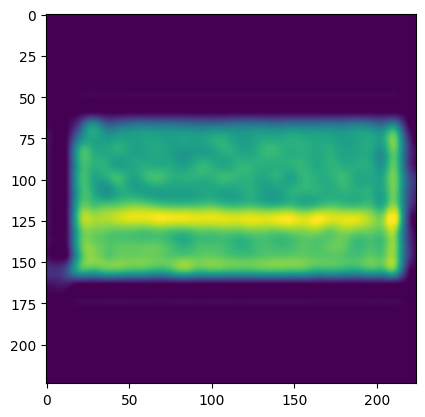

[8]


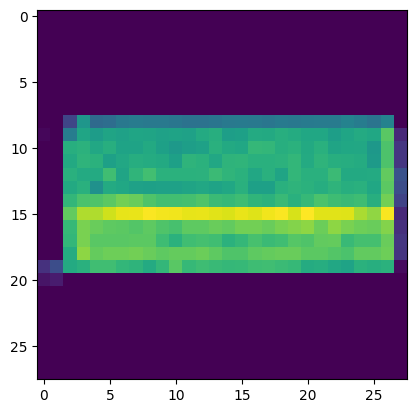

In [56]:
ind = 1000
# ind = 1001

plt.imshow(data_load['X'][ind,:,:])
plt.show()

paths_load = [
    r'../data/fashion-mnist/fashion-mnist_train.csv',
    r'../data/fashion-mnist/fashion-mnist_test.csv'
    ]

data = pd.read_csv(paths_load[0], low_memory=False).to_numpy()
X,y = data[:,1:], data[:,0].reshape(-1,1)
dims = X.shape
dims = [int(x) for x in [dims[0], np.sqrt(dims[1]), np.sqrt(dims[1])]]
X = X.reshape(dims)
print(y[ind])

plt.imshow(X[ind,:,:])
plt.show()